`conda activate r_env_standr`

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(dplyr)
    library(here)
    library(tibble)
    library(dittoSeq)
    library(stringr)
    library(data.table)
    library(tidyverse)
    library(patchwork) 
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(magrittr)
    library(patchwork)
    library(Seurat)
    library(scCustomize)
    library(reticulate)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

### Braun2023 predictions

#### Detailed annotations (Mossi et al.)

In [2]:
braun2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_seurat_v4_predictions_Braun2023_detailed.rds')
braun2023

An object of class Seurat 
19261 features across 258867 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.braun2023.celltype
 2 dimensional reductions calculated: pca, umap

In [3]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [4]:
braun2023 <- AddMetaData(braun2023, metadata = nmf_assignment)

In [5]:
braun2023$NMF <- braun2023$MP_Assignment

In [6]:
braun2023$NMF <- sub("_1$", "", braun2023$NMF)
braun2023$NMF <- factor(braun2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [9]:
unique(braun2023$predicted.braun2023.celltype)

[1] "Pre-OPC"       "Neuron"        "Radial glia"   "Pre-astrocyte"
 [5] "Neural crest"  "OPC"           "Fibroblast"    "COP"          
 [9] "Vascular"      "Erythrocyte"   "Neuronal IPC"  "Neuroblast"   
[13] "Glioblast"

In [13]:
braun2023$NMF <- factor(braun2023$NMF,
                       levels=c('MP_4','MP_11','MP_2','MP_5','MP_8','MP_3','MP_12','MP_7', 'MP_9', 'MP_13', 'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


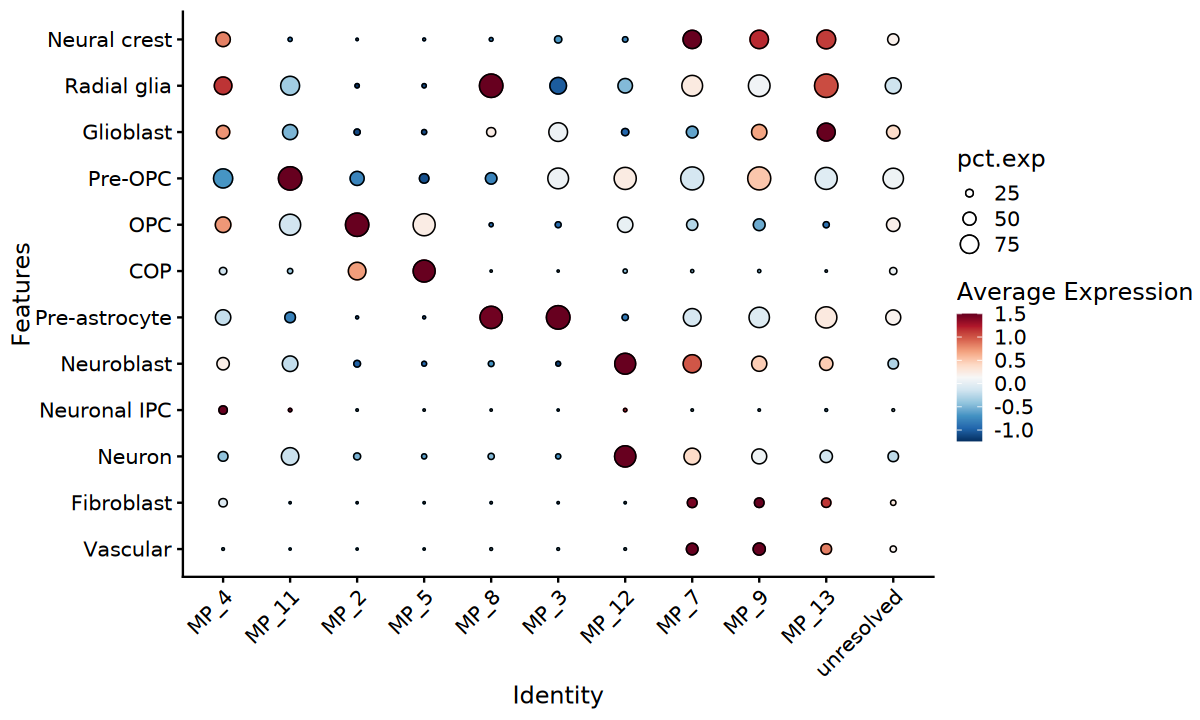

In [14]:
options(repr.plot.height = 6, repr.plot.width = 10)
DotPlot(braun2023, features = rev(c('Neural crest','Radial glia','Glioblast',
                                    'Pre-OPC','OPC','COP',
                                    'Pre-astrocyte',
                                    'Neuroblast','Neuronal IPC','Neuron',
                                    'Fibroblast','Vascular')), 
        group.by = 'NMF', assay = 'prediction.score.braun2023.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [15]:
ggsave('figures/braun2023_predicitons_dotplot_ordered.pdf', height = 4, width = 7)

### Wang2024 predictions

In [2]:
wang2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_seurat_v4_predictions_Wang2024.rds')
wang2024

An object of class Seurat 
19313 features across 258867 samples within 3 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.wang2024.celltype, prediction.score.wang2024_subset.celltype
 2 dimensional reductions calculated: pca, umap

In [3]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [4]:
wang2024 <- AddMetaData(wang2024, metadata = nmf_assignment)

In [5]:
wang2024$NMF <- wang2024$MP_Assignment

In [6]:
wang2024$NMF <- sub("_1$", "", wang2024$NMF)
wang2024$NMF <- factor(wang2024$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [9]:
unique(wang2024$predicted.wang2024_subset.celltype)

[1] "IPC-Glia"                 "IN-dLGE-Immature"        
 [3] "EN-Newborn"               "Astrocyte-Fibrous"       
 [5] "OPC"                      "Oligodendrocyte-Immature"
 [7] "Astrocyte-Immature"       "EN-Non-IT-Immature"      
 [9] "Oligodendrocyte"          "RG-vRG"

In [10]:
wang2024$NMF <- factor(wang2024$NMF,
                       levels=c('MP_4','MP_11','MP_2','MP_5','MP_8','MP_3','MP_12','MP_7', 'MP_9', 'MP_13', 'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


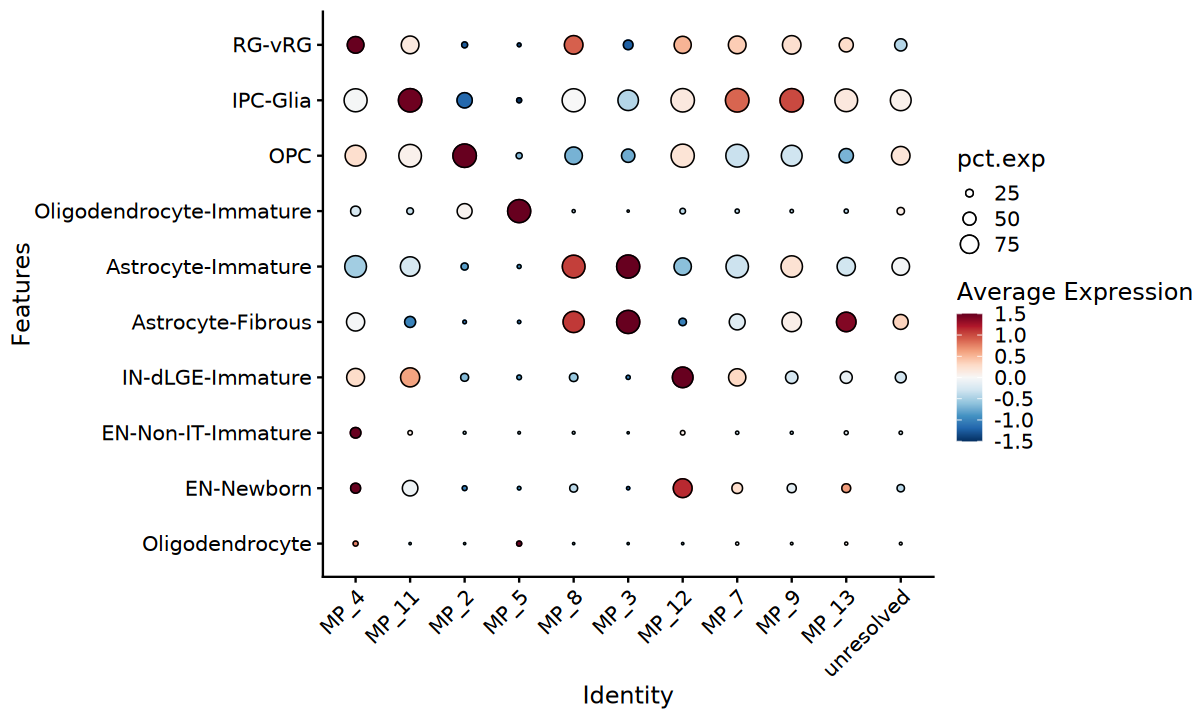

In [11]:
options(repr.plot.height = 6, repr.plot.width = 10)
DotPlot(wang2024, features = rev(c('RG-vRG','IPC-Glia',
                                   'OPC','Oligodendrocyte-Immature',
                                   'Astrocyte-Immature','Astrocyte-Fibrous',
                                   'IN-dLGE-Immature','EN-Non-IT-Immature','EN-Newborn',
                                   'Oligodendrocyte'
                                   )), 
        group.by = 'NMF', assay = 'prediction.score.wang2024_subset.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [12]:
ggsave('figures/wang2024_predicitons_dotplot_ordered.pdf', height = 3.6, width = 8)

### Li2023 predictions

In [13]:
li2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_seurat_v4_predictions_Li2023.rds')
li2023

An object of class Seurat 
19290 features across 258867 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.li2023.celltype
 2 dimensional reductions calculated: pca, umap

In [14]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [15]:
li2023 <- AddMetaData(li2023, metadata = nmf_assignment)

In [16]:
li2023$NMF <- li2023$MP_Assignment

In [17]:
li2023$NMF <- sub("_1$", "", li2023$NMF)
li2023$NMF <- factor(li2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [20]:
unique(li2023$predicted.li2023.celltype)

[1] "Pre-OPC"            "RG"                 "Early OPC-1"       
 [4] "APC2"               "APC1"               "Committed OPC"     
 [7] "Oligodentrocyte"    "Neuron precursor 1" "Early OPC-2"       
[10] "RGlikePC3"          "Early OPC-3"

In [22]:
li2023$NMF <- factor(li2023$NMF,
                       levels=c('MP_4','MP_11','MP_2','MP_5','MP_8','MP_3','MP_12','MP_7', 'MP_9', 'MP_13', 'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


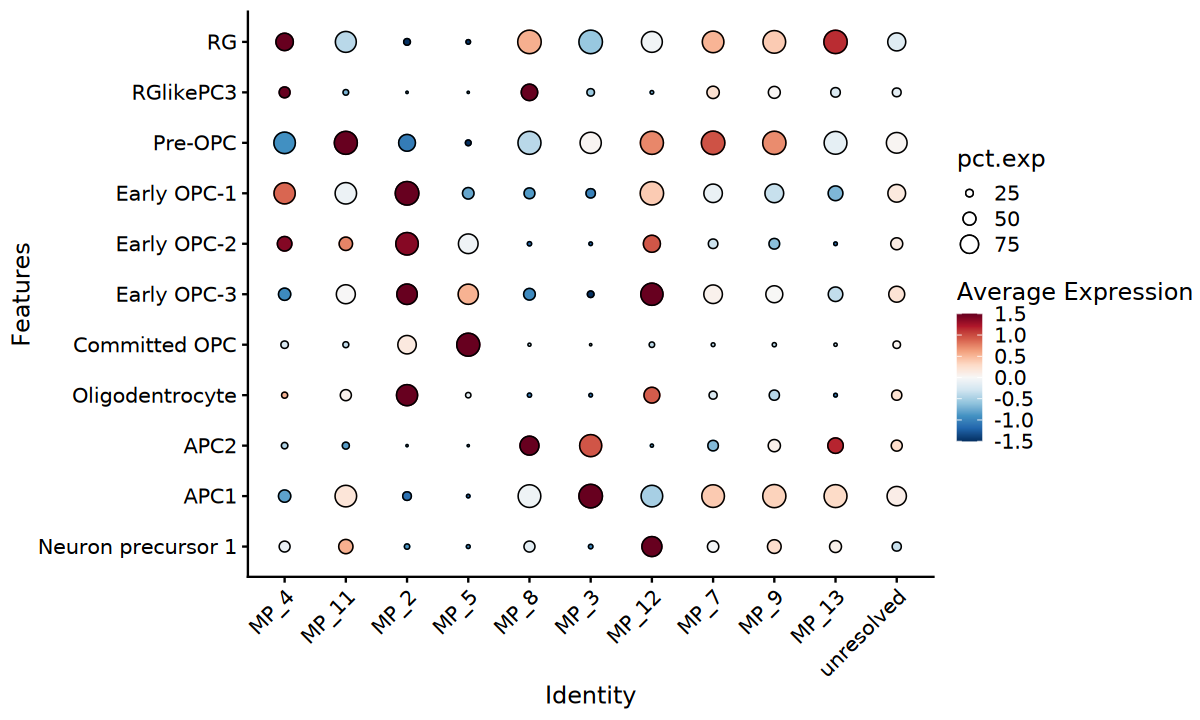

In [23]:
options(repr.plot.height = 6, repr.plot.width = 10)
DotPlot(li2023, features = rev(c('RG','RGlikePC3','Pre-OPC','Early OPC-1','Early OPC-2','Early OPC-3',
                                              'Committed OPC','Oligodentrocyte','APC2','APC1','Neuron precursor 1'
                                              )), 
        group.by = 'NMF', assay = 'prediction.score.li2023.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
    scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [24]:
ggsave('figures/li2023_predicitons_dotplot_ordered.pdf', height = 3.8, width = 7.4)

### Braun2023 and Siletti predictions

#### Detailed annotations (Mossi et al.)

In [37]:
braun2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_seurat_v4_predictions_Braun2023_Siletti2023.rds')
braun2023

An object of class Seurat 
19289 features across 58339 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.siletti.DetailedCellClass
 2 dimensional reductions calculated: pca, umap

In [38]:
nmf_assignment <- readRDS('nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [39]:
braun2023 <- AddMetaData(braun2023, metadata = nmf_assignment)

In [40]:
braun2023$NMF <- braun2023$MP_Assignment

In [41]:
braun2023$NMF <- sub("_1$", "", braun2023$NMF)
braun2023$NMF <- factor(braun2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

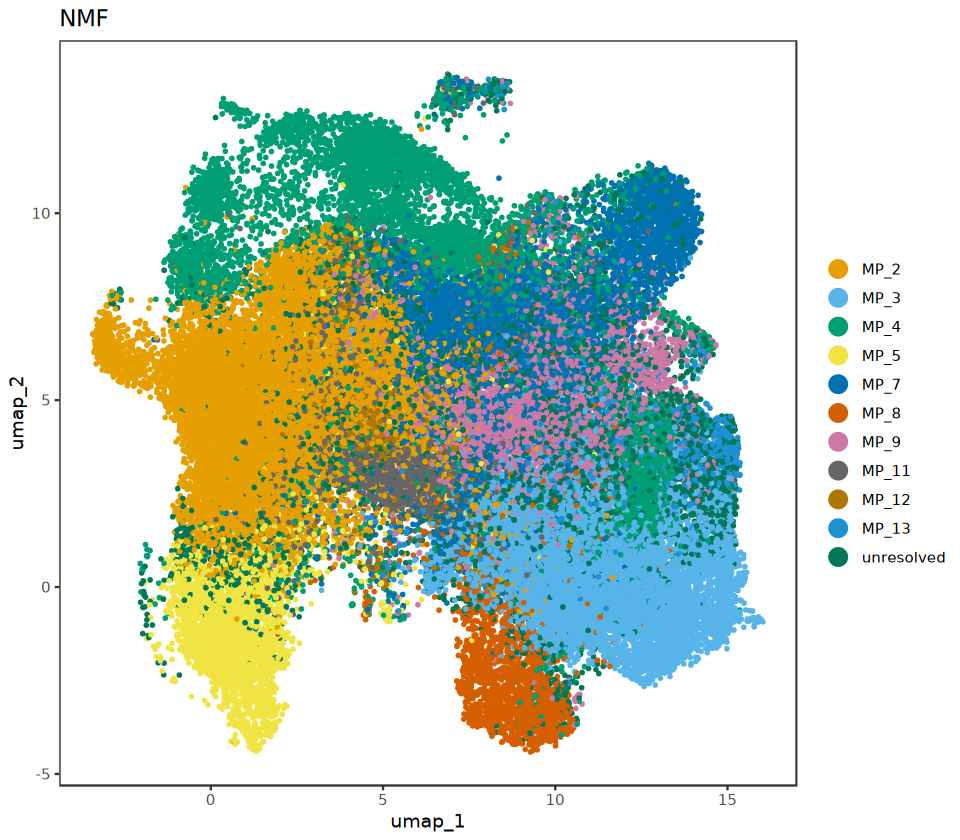

In [42]:
options(repr.plot.height = 7, repr.plot.width = 8)
dittoSeq::dittoDimPlot(braun2023, var = 'NMF',)

In [43]:
table(braun2023$NMF)


      MP_2       MP_3       MP_4       MP_5       MP_7       MP_8       MP_9 
     14374      10247       8031       3072       6458       1985       3893 
     MP_11      MP_12      MP_13 unresolved 
      2253        819       1261       5946 

In [44]:
unique(braun2023$predicted.siletti.DetailedCellClass)

[1] "Neuron"                              "Astrocyte"                          
 [3] "Radial glia"                         "Pre-OPC"                            
 [5] "OPC"                                 "Pre-astrocyte"                      
 [7] "Oligodendrocyte"                     "Committed oligodendrocyte precursor"
 [9] "Oligodendrocyte precursor"           "Ependymal"                          
[11] "Vascular"                            "Microglia"                          
[13] "Miscellaneous"                       "Neuroblast"                         
[15] "Glioblast"

In [45]:
braun2023$NMF <- factor(braun2023$NMF,
                       levels=c('MP_4','MP_11','MP_2','MP_5','MP_8','MP_3','MP_12','MP_7', 'MP_9', 'MP_13', 'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


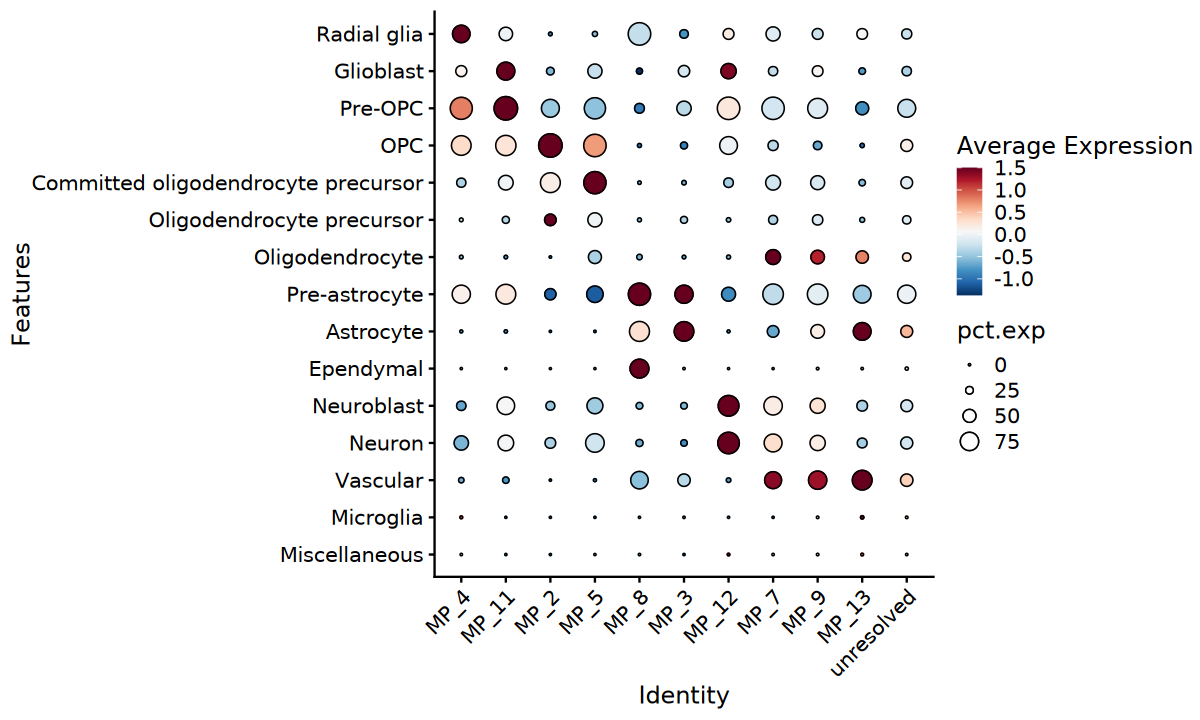

In [46]:
options(repr.plot.height = 6, repr.plot.width = 10)
DotPlot(braun2023, features = rev(c('Radial glia','Glioblast',
                                    'Pre-OPC','OPC','Committed oligodendrocyte precursor','Oligodendrocyte precursor','Oligodendrocyte',
                                    'Pre-astrocyte','Astrocyte','Ependymal',
                                    'Neuroblast','Neuron',
                                    'Vascular','Microglia','Miscellaneous')), 
        group.by = 'NMF', assay = 'prediction.score.siletti.DetailedCellClass',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [47]:
ggsave('figures/braun2023_siletti_predicitons_dotplot_ordered.pdf', height = 5, width = 9)